In [133]:
import os
import baltic as bt
import pandas as pd
from datetime import datetime, timedelta, date
from collections import OrderedDict
import numpy as np
from collections import defaultdict, Counter
from plotnine import *
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
from io import StringIO as sio
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
import plotly.express as px

In [134]:
def decimal_year_to_datetime(decimal_year):
    year = int(decimal_year)
    remainder = decimal_year - year

    start = datetime(year, 1, 1)
    end = datetime(year + 1, 1, 1)

    return start + timedelta(seconds=remainder * (end - start).total_seconds())

In [135]:
def load_tree(nexusPath):
    mytree = bt.loadNexus(nexusPath, tip_regex='\|([0-9]{4}\-[0-9]{2}\-[0-9]{2})', absoluteTime=True, verbose=False) # your tip regex might have to change or you could convert you tree into a newick by deleting everything before the tree string lol
    return(mytree)

In [136]:
nexusPath = "../H5N5-seabird-phylo/BEAST/cont-phyl_dta/results/2026-08-04_A6_concat_genome_traits_TEST/A6_concat-gen_traits_2026-08-04_MCC.tree"

In [137]:
tree = load_tree(nexusPath)

In [138]:
traitName = "region"

In [139]:
tree.treeStats()


Tree height: 6.003206
Tree length: 113.765981
strictly bifurcating tree

Numbers of objects in tree: 723 (361 nodes and 362 leaves)



In [8]:
# Use this code to print some info if you want it

count = 0

for k in tree.Objects:
    if count < 10:
        if k.is_node():
            count += 1
            print(k.absoluteTime)

2020.048849270397
2021.083493163454
2021.1306878662592
2021.387224264426
2021.4619137743098
2021.4910504729464
2021.5374680799925
2021.5257025966043
2021.9384889220428
2022.622821400785


In [140]:
h5n5_host_colors = {"seab":"#6AA1F4",
          "bdpr":"#F69BA6",
          "gds":"#6A994E",
          "mammal":"#A874D2",
          "scav":"#923E4D",
          "grdbd":"#E9C46A"
 #         "other":"#95A8B0"
         }

h5n5_region_colors = {"europe":"#ffaaaa",
          "east-canada":"#95b8d1",
          "northeast-us":"#f7df7d",
          "north-canada":"#ba9cc9",
          "northwest-us":"#94bf73",
          "asia":"#b09a6e"
         }

In [141]:
continent_dict = {"north-canada":"north-america",
                  "northeast-us":"north-america",
                  "northwest-us":"north-america",
                  "asia":"asia",
                  "east-canada":"north-america",
                  "europe":"europe",
                  "ancestor":"ancestor"
                 }

labels = {"seab":"Seabirds and Shorebirds",
          "bdpr":"Birds of Prey",
          "gds":"Geese, ducks, and seaducks",
          "mammal":"Mammals",
          "scav":"Scavengers",
          "grdbd":"Ground birds"
         # "other":"#95A8B0"
         }

# labels = {"europe":"Europe",
#           "east-canada":"Eastern Canada",
#           "new-england":"New England",
#           "north-canada":"Northern Canada",
#           "pacific-northwest":"Pacific Northwest (USA)",
#           "asia":"Asia"
#          }

In [11]:
def extract_subtrees(tree, traitName, dictionary):
    
    # tree_strings = defaultdict(list)
    subtype_trees = defaultdict(list)
    region_transitions = Counter()
    continent_transitions = Counter()

    for t in tree.Objects:  # Iterate over branches
        k = t  # branch
        kp = t.parent  # branch's parent

        # Get current node's and its parent's trait states
        kc = k.traits.get(traitName, 'ancestor') # Current branch trait value
        kpc = kp.traits.get(traitName, 'ancestor')  # Parent branch trait value

        # I only want to expand subtrees by introductions into North America
        kcont = dictionary[k.traits.get(traitName, 'ancestor')] # Current branch continent
        kpcont = dictionary[kp.traits.get(traitName, 'ancestor')] # Parent branch continent
        # print(f"Node: {k} - Trait: {kcont} | Parent: {kp} - Trait: {kpcont}")

        # # Debug: print current and parent trait states
        # print(f"Node: {k} - Trait: {kc} | Parent: {kp} - Trait: {kpc}")
        # Node: <baltic.baltic.node object at 0x110ae8850> - Trait: europe | Parent: <baltic.baltic.node object at 0x1326a9ad0> - Trait: ancestor

        # Count transitions
        if kpc != kc:
            region_transitions[(kpc, kc)] += 1
            # print(f"Transition detected: {kpc} -> {kc}")

        if kpcont != kcont:
            continent_transitions[(kpc, kc)] += 1

        # If continents do not match, extract subtree
        if kcont != kpcont:
            # traverse_condition = lambda w: w.traits.get(traitName, 'ancestor') == kc
            traverse_condition = lambda w: dictionary[w.traits.get(traitName, 'ancestor')] == kcont
            # print('subtree resulting from %s>%s switch, traversing within %s'%(kpcont,kcont,kcont))
            subtree = tree.subtree(k, traverse_condition=traverse_condition)
            
            if subtree:
                # print(f"Subtree extracted for transition: {kpc} -> {kc}")
                subtree.traverse_tree() 
                subtree.sortBranches()
                subtype_trees[kcont].append((kpcont, subtree))
                # tree_strings[kcont].append(subtree.toString())
                # print("Original node:", k.traits)
                # print("Same object?", subtree.root is k)
                # print(k.traits, subtree.root.children[0].traits)
            else:
                print(f"Subtree extraction failed for {kpcont} -> {kcont}")


    # # Debug: Print final structures
    # print(f"Tree Strings: {dict(tree_strings)}")
    print(f"Subtype Trees: {dict(subtype_trees)}")
    # print(f"Transitions: {dict(transitions)}")

    return subtype_trees, dict(region_transitions), dict(continent_transitions)

In [12]:
#execute subtrees function
subtype_trees, region_transitions, continent_transitions = extract_subtrees(tree, traitName, continent_dict)

# Print subtype_trees to verify its content
print(f"transitions: {region_transitions}")
print(f"subtrees: {continent_transitions}")

Subtype Trees: {'europe': [('ancestor', <baltic.baltic.tree object at 0x3189abe50>), ('north-america', <baltic.baltic.tree object at 0x318a23610>), ('north-america', <baltic.baltic.tree object at 0x3197c8cd0>), ('north-america', <baltic.baltic.tree object at 0x3194562d0>), ('north-america', <baltic.baltic.tree object at 0x319056350>)], 'north-america': [('europe', <baltic.baltic.tree object at 0x318570510>), ('europe', <baltic.baltic.tree object at 0x3187e0c90>), ('europe', <baltic.baltic.tree object at 0x318fc7450>), ('europe', <baltic.baltic.tree object at 0x319290790>), ('europe', <baltic.baltic.tree object at 0x3192e4cd0>), ('europe', <baltic.baltic.tree object at 0x319021cd0>), ('europe', <baltic.baltic.tree object at 0x318707f90>), ('europe', <baltic.baltic.tree object at 0x3195afa90>), ('europe', <baltic.baltic.tree object at 0x3187a6110>)], 'asia': [('europe', <baltic.baltic.tree object at 0x318e33b50>), ('europe', <baltic.baltic.tree object at 0x3197939d0>)]}
transitions: {('a

In [13]:
# Plot the number of transitions from one continent to another

transition_start_list = []
transition_end_list = []
counts_list = []

# Loop through the transitions dictionary
for (from_state, to_state), count in region_transitions.items():
    transition_start_list.append(from_state)
    transition_end_list.append(to_state)
    counts_list.append(count)  # Get the corresponding count

# Create a DataFrame
transitions_df = pd.DataFrame({'Start': transition_start_list, "End": transition_end_list, 'Count': counts_list})

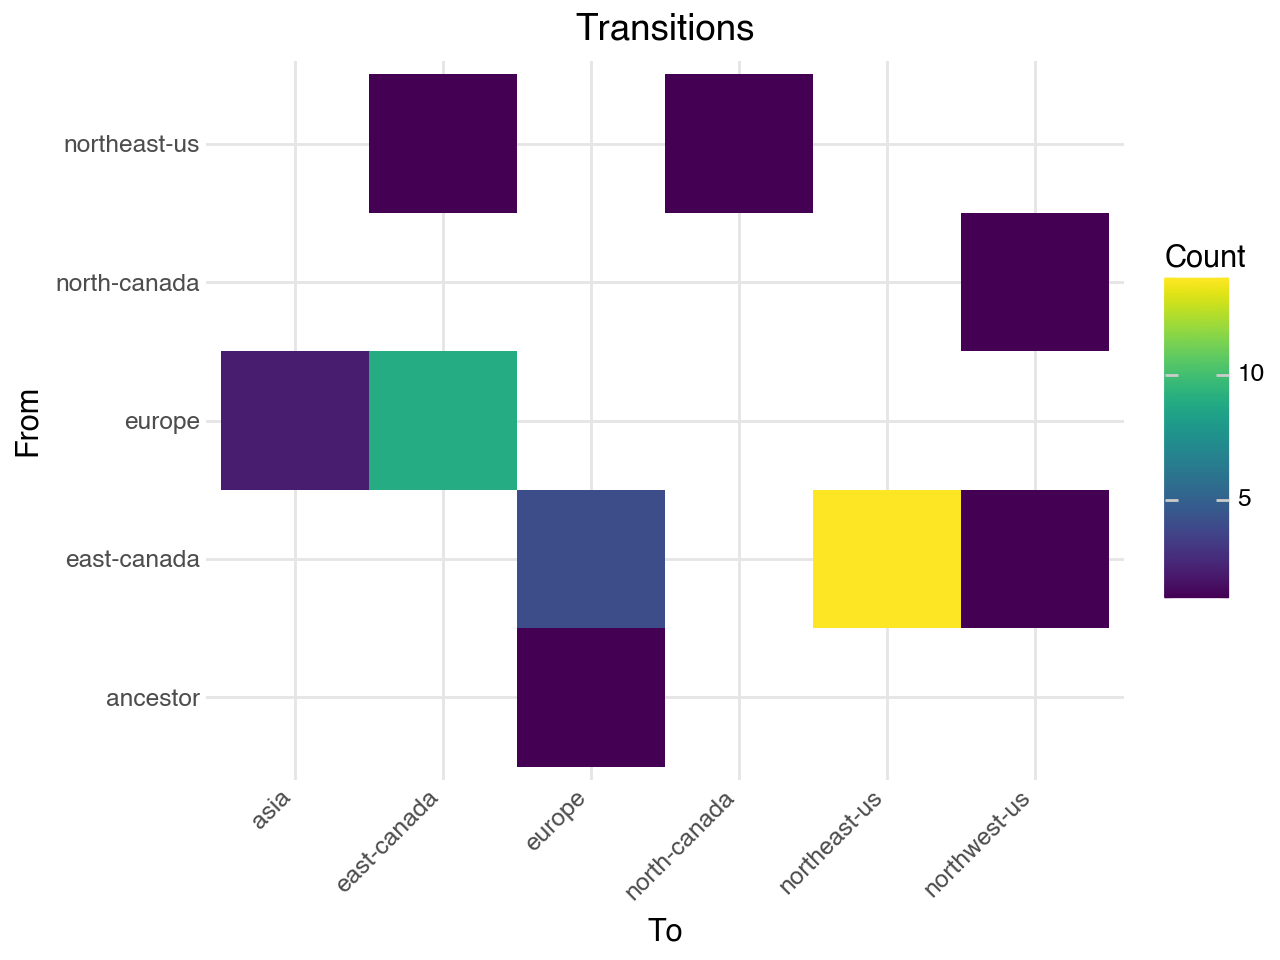

          Start           End  Count
0      ancestor        europe      1
1        europe   east-canada      9
2        europe          asia      2
3   east-canada  northeast-us     14
4   east-canada  northwest-us      1
5  northeast-us  north-canada      1
6  north-canada  northwest-us      1
7   east-canada        europe      4
8  northeast-us   east-canada      1


In [14]:
transitions_plot = (
    ggplot(transitions_df, aes(x = "End", y = "Start", fill = "Count")) 
    + geom_tile() 
    + labs(title = "Transitions", x = "To", y = "From")
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=45, hjust=1))
)

transitions_plot.show()
print(transitions_df)

In [17]:
def subtree_to_dataframe_with_origin(subtype_trees, traitName, most_recent_date):
    # List to hold all subtree data
    all_subtree_data = []

    # Iterate over each subtype and its associated subtrees
    for subtype, subtree_list in subtype_trees.items():
        for i, (origin, subtree) in enumerate(subtree_list):
            # Extract the origin date, assuming it's the root's absoluteTime minus its length
            if subtree.root.absoluteTime == None: # ancestral root
                origin_date = most_recent_date - subtree.treeHeight
            else:
                origin_date = subtree.root.absoluteTime - subtree.root.length
            # origin_date = subtree.root.date
            
            # Iterate through nodes in the subtree
            for node in subtree.Objects:
                # Collect relevant information from each node
                node_info = {
                    'branchType': node.branchType,  # 'leaf' or 'internal'
                    'date': node.absoluteTime,
                    # 'date': node.date,
                    'length': node.length,
                    'origin': origin,  # Include the origin trait
                    'origin_date': origin_date,  # Add the origin date here
                    'subtree_name': f"{subtype}_{i}",  # Unique name for the subtree
                    'traits': node.traits  # This is a dictionary; we can expand it later if needed
                }
                
                # Expand the traits dictionary into individual columns
                for trait, value in node.traits.items():
                    node_info[trait] = value  # Each trait becomes its own column

                # Add this node's information to the list
                all_subtree_data.append(node_info)
    
    # Convert the list of dictionaries into a DataFrame
    df = pd.DataFrame(all_subtree_data)
    
    # Drop the node_attrs column if it exists (assuming it may not be needed)
    if 'node_attrs' in df.columns:
        df.drop(columns=['node_attrs', 'traits'], inplace=True)

    return df

In [18]:
# execute function and store in combined df

combined_df = subtree_to_dataframe_with_origin(subtype_trees, traitName, 2026.0520547945205)
# combined_df.head(5)  # Display the first 10 rows of the DataFrame

In [19]:
def make_subtree_df(combined_df):
    # Function to convert decimal year to date
    def decimal_year_to_date(decimal_year):
        year = int(decimal_year)
        decimal_part = decimal_year - year
        days_in_year = 365.25  # Average including leap years
        day_of_year = int(decimal_part * days_in_year)
        return datetime(year, 1, 1) + timedelta(days=day_of_year)

    # Make a new DataFrame that pulls out only leaf nodes and groups by subtree_name
    tip_counts = combined_df[combined_df['branchType'] == 'leaf'].groupby('subtree_name').size().reset_index(name='leaf_count')

    # Make separate sub DataFrame that pulls out the origin date, origin, and trait of tips of each subtree
    origin_info = combined_df[['subtree_name', 'origin_date', 'origin', 'region']].drop_duplicates()

    # Merge origin sub DataFrame into tip_counts
    tip_counts = pd.merge(tip_counts, origin_info, on='subtree_name')

    # Filter to only include leaf nodes
    leaf_nodes = combined_df[combined_df['branchType'] == 'leaf']

    # Group by 'subtree_name' and get the max absoluteTime for each subtree
    last_tip_dates = leaf_nodes.groupby('subtree_name')['date'].max().reset_index()

    # Rename the column to 'last_tip_date'
    last_tip_dates.rename(columns={'date': 'last_tip_date'}, inplace=True)

    # Merge more recent tip dates into the tip_counts sub DataFrame
    tip_counts = tip_counts.merge(last_tip_dates, on='subtree_name', how='left')

    # Convert origin_date and last_tip_date to datetime
    tip_counts['origin_date'] = tip_counts['origin_date'].apply(decimal_year_to_date)
    tip_counts['last_tip_date'] = tip_counts['last_tip_date'].apply(decimal_year_to_date)

    # Now calculate and add persistence times in days
    tip_counts['subtree_duration_days'] = (tip_counts['last_tip_date'] - tip_counts['origin_date']).dt.days

    # Round the persistence times
    tip_counts['subtree_duration_days'] = tip_counts['subtree_duration_days'].round(1)

    # Return the final DataFrame
    return tip_counts

In [20]:
# execute function of making subtree dataframe for subtree analyses
tip_counts = make_subtree_df(combined_df)

In [21]:
mpl.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})

In [81]:
def plot_tree(traitName, subtype_trees, tree, MRSD, continent_dict, colors, save_path, fig_size=(20, 20)):

    origin_shape = {"europe":"s","east-canada":"^","northeast-us":"^","north-canada":"^","northwest-us":"^","asia":"v"}
    
    # Define the subtypes, since they're different from the colors
    subtypes = ["europe", "asia", "north-america"]

    # Initialize figure and cumulative y offset
    fig = plt.figure(figsize=fig_size, facecolor='w')
    gs = gridspec.GridSpec(1, 1, wspace=0.0)
    ax = plt.subplot(gs[0], facecolor='w')

    # Functions for defining various attributes of objects
    c_func = lambda k: colors.get(k.traits[traitName], 'grey')
    tipSize = 20
    s_func = lambda k: origin_shape.get(k.traits.get("region"), "o") # set the shape based on the continent, default is circle

    cumulative_y = 0
    y_func = lambda k: k.y + cumulative_y # Function to update y-attribute with cumulative offset

    # d_func = lambda d: (decimal_year_to_datetime(d)).strftime("%b %d %Y") 

    # most_recent_sampling_date = 2026.0520547945205

    tree_counter = 0

    # Iterate over each trait and its subtrees  
    for subtype in subtypes:
        
        # for t, tr in enumerate(sorted(subtype_trees[subtype], key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects)))):
        for t, tr in enumerate(sorted(subtype_trees[subtype], key=lambda x: (len(x[1].Objects)))): # For each tree
            origin, loc_tree = tr
            subtree = tr[1]
            tree_counter += 1

            for k in subtree.Objects:
                x = k.absoluteTime
                y = y_func(k)
                s = tipSize
                # print(min(k.absoluteTime for k in subtree.Objects if k.is_node()))
                
                if k == subtree.root:
                    if origin == "ancestor":
                        x = MRSD - subtree.treeHeight
                        ax.scatter(x, y, s = 60, facecolor = "black", edgecolor = "white", zorder = 11)
                    else:
                        ax.scatter(x, y, s = 60 if s_func(k) == "^" else 50, facecolor = c_func(k), edgecolor = "white", zorder = 11, marker = s_func(k))
                elif k.branchType == "node":
                    n_children = len(k.leaves)
                    xp = k.parent.absoluteTime
                    ax.plot([x,x], [y_func(k.children[-1]), y_func(k.children[0])], color = c_func(k), zorder = 9) # this is the vertical line connecting children 
                    ax.plot([xp,x],[y,y],color=c_func(k),ls='-',zorder=9) # this is the horizontal line connecting nodes
                elif k.branchType == "leaf":
                    xp = k.parent.absoluteTime
                    ax.scatter(x,y,s=s,facecolor=c_func(k),edgecolor='none',zorder=11) # plot circle for every tip
                    ax.scatter(x,y,s=s+0.8*s,facecolor='k',edgecolor='none',zorder=10) # plot black circle underneath
                    ax.plot([xp,x],[y,y],color=c_func(k),ls='-',zorder=9) # this is the horizontal line connecting nodes 
                        
            cumulative_y += loc_tree.ySpan + 5 # Update y for the next tree

    print(f"Number of subtrees: {tree_counter}")
            
    # Axis and plot styling
    ax.xaxis.tick_bottom()
    ax.yaxis.tick_left()
    [ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left']]
    ax.tick_params(axis='x', size=0, labelsize=25)
    ax.tick_params(axis='y', size=0)
    ax.grid(axis='x', ls='--')
    
    # Set y-axis limits and remove labels
    ax.set_yticklabels([])
    ax.set_ylim(-15, cumulative_y + 15)
    
    # Determine the min and max dates in the tree
    min_date = min(k.absoluteTime for k in tree.Objects if k.is_node())
    max_date = max(k.absoluteTime for k in tree.Objects if k.is_node())

    # Add in dashed lines at the midpoints as well
    xticks = ax.get_xticks()
    midpoints = np.mean([xticks[:-1], xticks[1:]], axis=0)
    ax.vlines(midpoints, *ax.get_ylim(), linestyles='--', colors='gray', linewidth = 0.8, alpha = 0.4)
    
    # Set x-axis limits with some padding
    padding = 0.3  # Adjust padding as desired
    ax.set_xlim(min_date - padding, max_date + padding)    
    
    # Legend setup
    # handles = [
    #     plt.Line2D([0], [0], marker='o', color='w', label=label,
    #                markersize=10, markerfacecolor=color)
    #     for label, color in colors.items()
    # ]
    # plt.legend(handles=handles, title='Traits', loc=legend_loc)
    
    # Adjust layout and show plot
    plt.gcf().subplots_adjust(right=0.88)
    # plt.title(treename + "_" + todays_date)
    output_filename = save_path
    plt.savefig(output_filename, format='png')
    plt.show()

Number of subtrees: 16


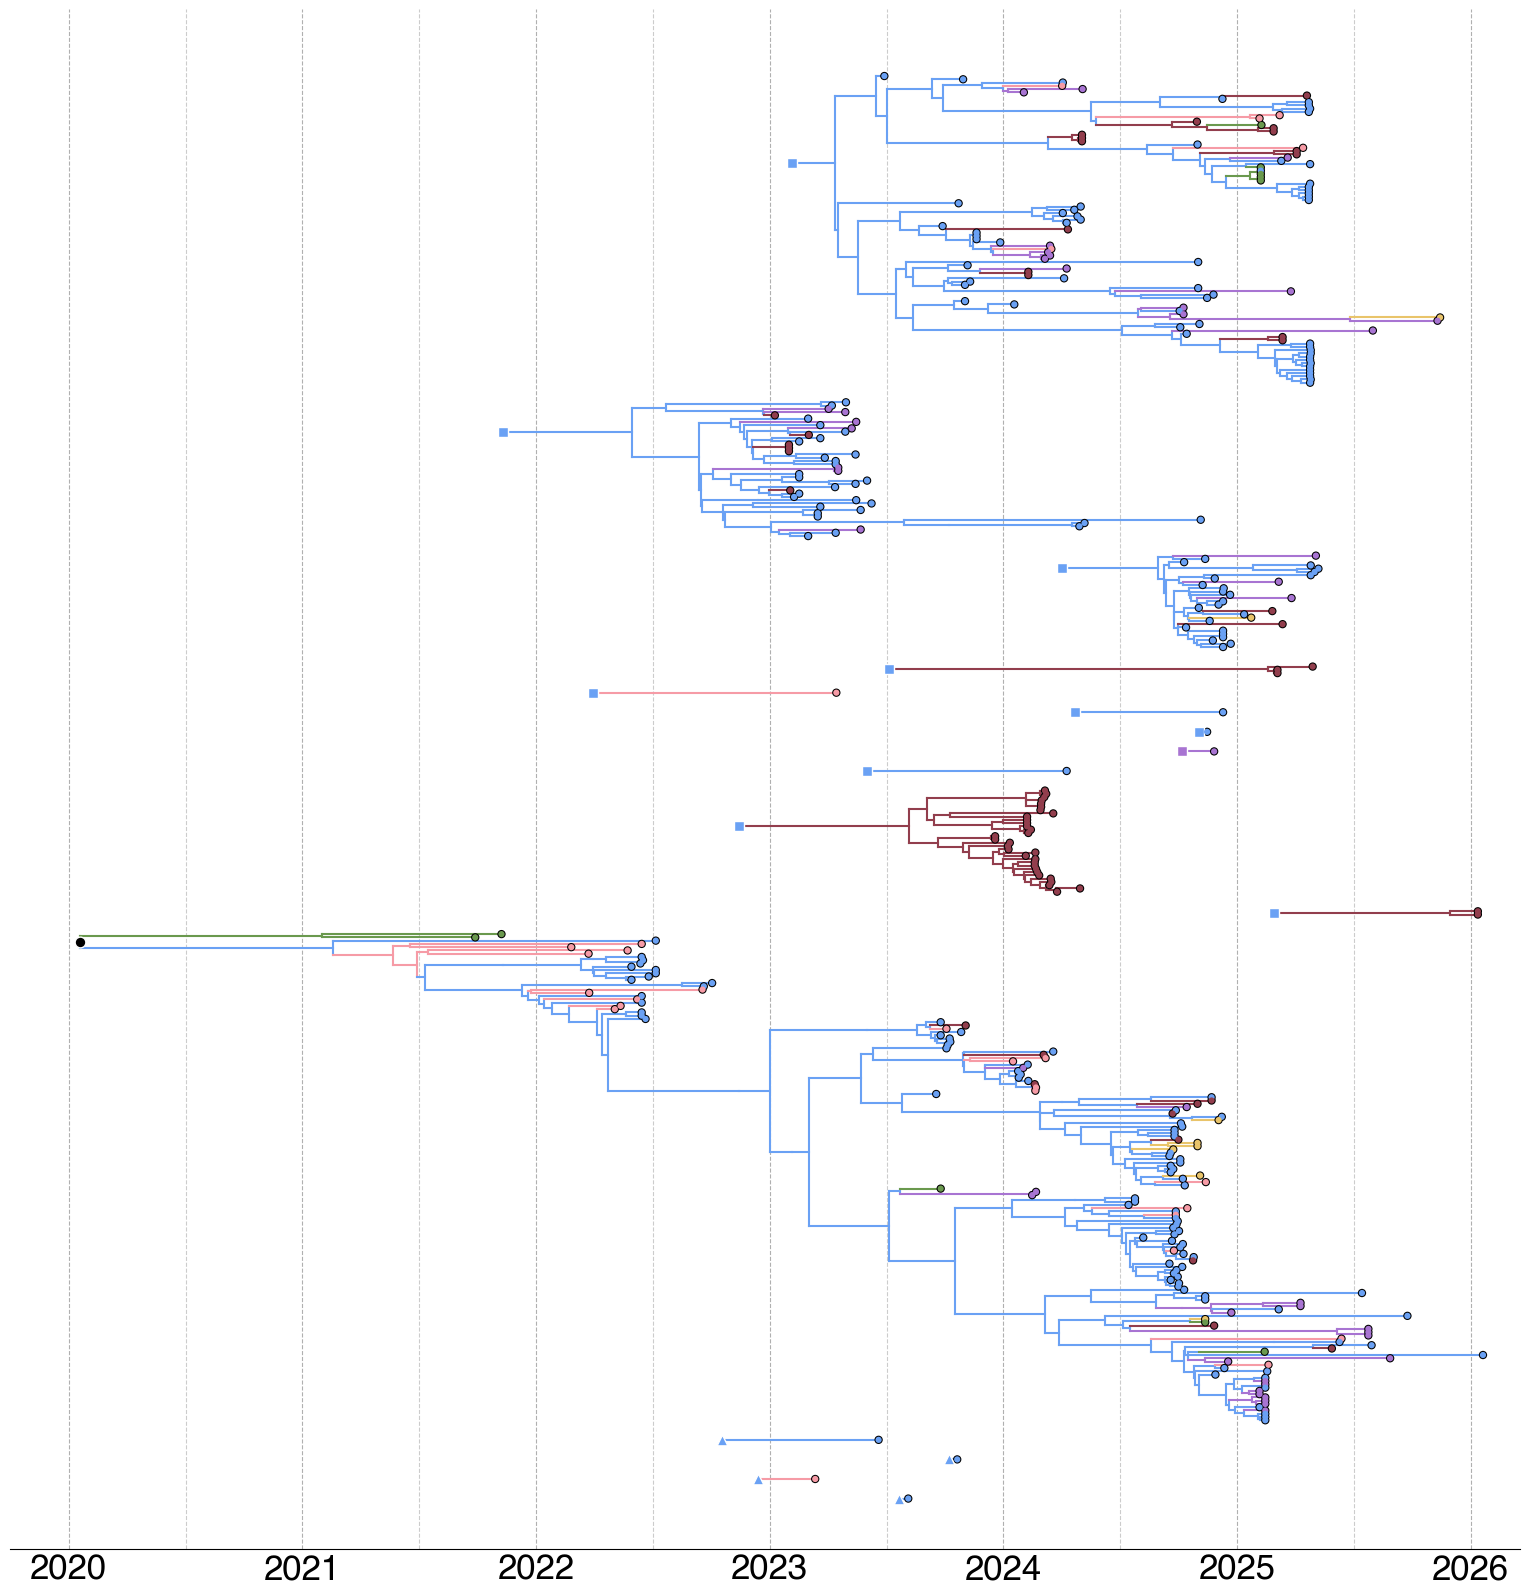

In [82]:
# Define color scheme for traits

# plot_tree("region", subtype_trees, tree, 2026.0520547945205, continent_dict, h5n5_region_colors, "./SERAPHIM/plots/exploded_A6-concat-gen_2026-08-04_region.png", fig_size=(20, 20))
plot_tree("host", subtype_trees, tree, 2026.0520547945205, continent_dict, h5n5_host_colors, "./SERAPHIM/plots/exploded_A6-concat-gen_2026-08-04_host.png", fig_size=(20, 20))

In [142]:
# To measure the cryptic circulation in North America leading up to the human infection

cryptic_circulation_list = []

for obj in tree.Objects:
    if obj.traits["region"] == "northwest-us": 
        # print(obj) # There are 4 objects in northwest US: 3 leaves and 1 node
        if obj.branchType == "leaf":
            print(obj.name) # The leaves are a polar bear in Alaska and the human and related turkey in Washington
            # if "A/Washington/2148/2025" in obj.name:
            branchStart = obj.absoluteTime - obj.traits["length"]
            branchStartUpper = obj.absoluteTime - obj.traits["length_95%_HPD"][0]
            branchStartLower = obj.absoluteTime - obj.traits["length_95%_HPD"][1]
            cryptic_circulation_list.append([obj.name, "tip", 
                                             obj.absoluteTime, branchStart, [branchStartUpper, branchStartLower], 
                                             obj.length, obj.traits["length"], obj.traits["length_median"], obj.traits["length_95%_HPD"]])
        elif obj.branchType == "node": # In this case, I also want the branch length of the ancestor node of the human and turkey
            branchStart = obj.absoluteTime - obj.traits["length"]
            branchStartUpper = obj.absoluteTime - obj.traits["length_95%_HPD"][0]
            branchStartLower = obj.absoluteTime - obj.traits["length_95%_HPD"][1]
            cryptic_circulation_list.append(["turkey-human-ancestor", "node", 
                                             obj.absoluteTime, branchStart, [branchStartUpper, branchStartLower], 
                                             obj.length, obj.traits["length"], obj.traits["length_median"], obj.traits["length_95%_HPD"]])


mini_df = pd.DataFrame(cryptic_circulation_list).rename({0:"name", 1: "objectType", 
                                                         2: "objectTime", 3: "mostRecentAncestorTime", 4: "ancestorTime_95HPD", 
                                                         5: "branchLength", 6: "nodeLength", 7: "nodeLengthMedian", 8: "nodeLength_95HPD"}, 
                                                         axis = 1)
mini_df.head()

26G03248|A/Polar_Bear/AK/26G03248/2025|H5N5|North_America|2025-08-01|nonhuman_mammal|A6
EPI_ISL_20252012|A/Washington/2148/2025|H5N5|North_America|2025-11-10|human|A6
25G04434-001-v|A/Turkey/WA/25G04434-001-v/2025|H5N5|North_America|2025-11-14|domestic_avian|A6


,name,objectType,objectTime,mostRecentAncestorTime,ancestorTime_95HPD,branchLength,nodeLength,nodeLengthMedian,nodeLength_95HPD
0,26G03248|A/Polar_Bear/AK/26G03248/2025|H5N5|No...,tip,2025.580822,2024.602351,"[2024.7353814105652, 2024.4076212110886]",0.859920,0.978471,0.959444,"[0.8454405072422, 1.173200706719]"
1,turkey-human-ancestor,node,2025.484405,2024.496302,"[2024.8083387279291, 2024.2262437869883]",0.773613,0.988103,1.020496,"[0.6760666855292, 1.25816162647]"
2,EPI_ISL_20252012|A/Washington/2148/2025|H5N5|N...,tip,2025.857534,2025.664854,"[2025.8351413090106, 2025.38713064728]",0.373129,0.192680,0.154331,"[0.02239293756424, 0.470403599295]"
3,25G04434-001-v|A/Turkey/WA/25G04434-001-v/2025...,tip,2025.868493,2025.664854,"[2025.8351413090106, 2025.38713064728]",0.384088,0.203639,0.165290,"[0.0333518416739, 0.4813625034047]"
